In [1]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

import cartopy.crs as ccrs
import cartopy.feature

from matplotlib.colors import LinearSegmentedColormap

In [2]:
df = pl.read_parquet("Simulations/Simulation_Satellite_kN_0.001.parquet")

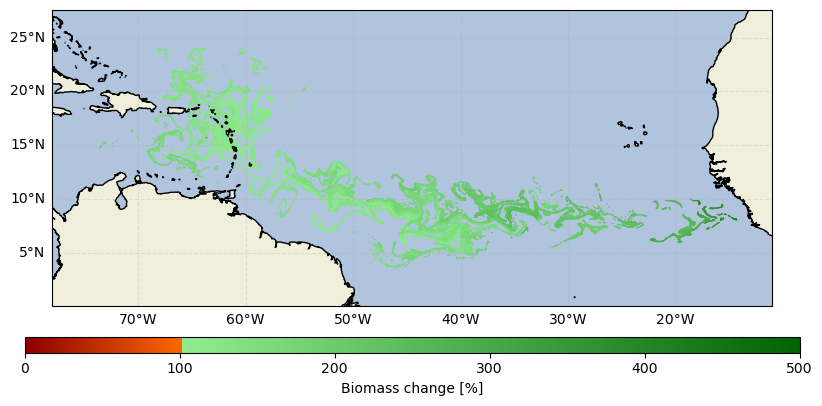

In [ ]:
fig = plt.figure(figsize = (10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_facecolor('lightsteelblue')
ax.gridlines(draw_labels=['left','bottom'], zorder=2, alpha=0.3, linestyle='--')

to_plot = (
    df.group_by('particle_id')
    .agg([
        pl.col('lon').last().alias('lon'),
        pl.col('lat').last().alias('lat'),
        (pl.col('biomass_SF3') * 100).last().alias('biomass')
    ])
    .sort('particle_id')
)

cmap = LinearSegmentedColormap.from_list(
    'red_orange_green',
    [(0.0, '#8b0000'), (0.2, '#ff6600'), (0.2, '#90ee90'), (1.0, '#006400')]
)

cscat = ax.scatter(to_plot['lon'], to_plot['lat'], c=to_plot['biomass'], s=1, linewidth=0,
                   cmap=cmap, vmin=0, vmax=500, transform=ccrs.PlateCarree(), zorder=1)

ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'), zorder=2)
ax.add_feature(cartopy.feature.LAND.with_scale('10m'))
ax.set_extent([-78, -11, 0, 24])

cbar = plt.colorbar(cscat, ax=ax, orientation='horizontal', pad=0.08, aspect=50, label='Biomass change [%]')

fig.savefig('Figures/Figure5.png', bbox_inches='tight', dpi=300)

plt.show()

In [4]:
print("Particle-averaged biomass change [%]:", to_plot['biomass'].mean())

Particle-averaged biomass change [%]: 160.65134820509752
